# ESG Portfolio Construction & Performance Analysis

## Portfolios:
1. **ESG Long-Short Best-in-Class (Quintile)** - Long top quintile, Short bottom quintile
2. **ESG Long-Short Best-in-Class (Decile)** - Long top decile, Short bottom decile
3. **ESG Weighted** - All stocks weighted by ESG score
4. **ESG Weighted Top Quintile** - Top 20% weighted by ESG
5. **ESG Weighted Top Decile** - Top 10% weighted by ESG

In [7]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import yfinance as yf
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

## 1. Load Data

**Modifiez les chemins ci-dessous pour pointer vers vos fichiers de données.**

In [8]:
# ============================================
# MODIFY THESE PATHS TO YOUR DATA FILES
# ============================================

# Path to ESG panel data
ESG_DATA_PATH = "C:/Users/anton/OneDrive/Bureau/Edhec course/Master 2/Research Thesis/Data-Analysis/Data/price_esg/ESG_Panel_With_Closing_Price.xlsx"

# Path to benchmark data
BENCHMARK_PATH = "C:/Users/anton/OneDrive/Bureau/Edhec course/Master 2/Research Thesis/Data-Analysis/Data/sp500_monthly_returns.xlsx"

# Risk-free rate (annual) from yahoo finance (e.g., 10-year US Treasury yield)
RF_RATE_ANNUAL = 0.02

In [9]:
# Load ESG Data
data = pd.read_excel(ESG_DATA_PATH, sheet_name="Panel Data")

# Data cleaning
data["Date"] = pd.to_datetime(data["Date"])
data["Closing_Price"] = pd.to_numeric(data["Closing_Price"], errors="coerce")
data = data.dropna(subset=["Closing_Price", "ESG"]).copy()

# Calculate returns
data = data.sort_values(["Ticker", "Date"])
data["Return"] = data.groupby("Ticker")["Closing_Price"].pct_change()

# Create quintiles and deciles (per date for cross-sectional ranking)
data["ESG_quintile"] = data.groupby("Date")["ESG"].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
)
data["ESG_decile"] = data.groupby("Date")["ESG"].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
)

# Drop NaN returns (first observation per ticker)
data = data.dropna(subset=["Return"])

print(f"Data shape: {data.shape}")
print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")
print(f"Number of stocks: {data['Ticker'].nunique()}")
data.head()

Data shape: (52421, 12)
Date range: 2015-02-01 00:00:00 to 2025-12-01 00:00:00
Number of stocks: 404


,Date,Ticker,Name,Sector,ESG,E,S,G,Closing_Price,Return,ESG_quintile,ESG_decile
1,2015-02-01,A,"Agilent Technologies, Inc.",Health Care,58,65,52,61,37.64,0.125262,3,7
2,2015-03-01,A,"Agilent Technologies, Inc.",Health Care,58,65,52,61,38.68,0.027630,3,7
3,2015-04-01,A,"Agilent Technologies, Inc.",Health Care,58,65,52,61,36.95,-0.044726,3,7
4,2015-05-01,A,"Agilent Technologies, Inc.",Health Care,58,65,52,61,37.53,0.015697,3,7
5,2015-06-01,A,"Agilent Technologies, Inc.",Health Care,58,65,52,61,34.64,-0.077005,3,7


In [10]:
# Load Benchmark Data
benchmark_data = pd.read_excel(BENCHMARK_PATH, sheet_name="Sheet1", parse_dates=["Date"])
benchmark_rets = benchmark_data[["Date", "Return"]].copy()
benchmark_series = benchmark_rets.set_index("Date")["Return"]

print(f"Benchmark date range: {benchmark_rets['Date'].min()} to {benchmark_rets['Date'].max()}")
benchmark_rets.head()

Benchmark date range: 2010-01-01 00:00:00 to 2025-12-01 00:00:00


,Date,Return
0,2010-01-01,-0.036870
1,2010-02-01,0.028514
2,2010-03-01,0.058796
3,2010-04-01,0.014759
4,2010-05-01,-0.081976


## 2. Portfolio Construction Functions

In [43]:
def create_long_short_quintile(data):
    """
    ESG Long-Short Best-in-Class (Quintile)
    Long top quintile (Q4), Short bottom quintile (Q0)
    Equal-weighted within each leg
    """
    quintile_returns = data.groupby(['Date', 'ESG_quintile'])['Return'].mean().unstack()
    max_q = quintile_returns.columns.max()
    min_q = quintile_returns.columns.min()
    return quintile_returns[max_q] - quintile_returns[min_q]


def create_long_short_decile(data):
    """
    ESG Long-Short Best-in-Class (Decile)
    Long top decile (D9), Short bottom decile (D0)
    Equal-weighted within each leg
    """
    decile_returns = data.groupby(['Date', 'ESG_decile'])['Return'].mean().unstack()
    max_d = decile_returns.columns.max()
    min_d = decile_returns.columns.min()
    return decile_returns[max_d] - decile_returns[min_d]

def create_long_only_quintile(data):
    """
    ESG Long Only Best-in-Class (Quintile)
    Long top quintile (Q4), no short leg
    Equal-weighted within the quintile
    """
    quintile_returns = data.groupby(['Date', 'ESG_quintile'])['Return'].mean().unstack()
    max_q = quintile_returns.columns.max()
    return quintile_returns[max_q]

def create_long_only_decile(data):
    """
    ESG Long Only Best-in-Class (Decile)
    Long top decile (D9), no short leg
    Equal-weighted within the decile
    """
    decile_returns = data.groupby(['Date', 'ESG_decile'])['Return'].mean().unstack()
    max_d = decile_returns.columns.max()
    return decile_returns[max_d]


def create_esg_weighted(data):
    """
    ESG Weighted Portfolio
    All stocks weighted proportionally to their ESG score
    """
    portfolio_returns = []
    for date, group in data.groupby('Date'):
        weights = group['ESG'] / group['ESG'].sum()
        weighted_return = (weights * group['Return']).sum()
        portfolio_returns.append({'Date': date, 'Return': weighted_return})
    return pd.DataFrame(portfolio_returns).set_index('Date')['Return']


def create_esg_weighted_top_quintile(data):
    """
    ESG Weighted Top Quintile
    Only top 20% ESG stocks, weighted by ESG score
    """
    portfolio_returns = []
    max_quintile = data['ESG_quintile'].max()
    
    for date, group in data.groupby('Date'):
        top_q = group[group['ESG_quintile'] == max_quintile]
        if len(top_q) > 0:
            weights = top_q['ESG'] / top_q['ESG'].sum()
            weighted_return = (weights * top_q['Return']).sum()
        else:
            weighted_return = 0
        portfolio_returns.append({'Date': date, 'Return': weighted_return})
    return pd.DataFrame(portfolio_returns).set_index('Date')['Return']


def create_esg_weighted_top_decile(data):
    """
    ESG Weighted Top Decile
    Only top 10% ESG stocks, weighted by ESG score
    """
    portfolio_returns = []
    max_decile = data['ESG_decile'].max()
    
    for date, group in data.groupby('Date'):
        top_d = group[group['ESG_decile'] == max_decile]
        if len(top_d) > 0:
            weights = top_d['ESG'] / top_d['ESG'].sum()
            weighted_return = (weights * top_d['Return']).sum()
        else:
            weighted_return = 0
        portfolio_returns.append({'Date': date, 'Return': weighted_return})
    return pd.DataFrame(portfolio_returns).set_index('Date')['Return']

In [44]:
# Build all portfolios
print("Building portfolios...")

portfolios = {
    'Long-Short Quintile': create_long_short_quintile(data),
    'Long-Short Decile': create_long_short_decile(data),
    'Long Only Quintile': create_long_only_quintile(data),
    'Long Only Decile': create_long_only_decile(data),
    'ESG Weighted': create_esg_weighted(data),
    'ESG Weighted Top Q': create_esg_weighted_top_quintile(data),
    'ESG Weighted Top D': create_esg_weighted_top_decile(data)
}

# Display sample
portfolio_df = pd.DataFrame(portfolios)
print(f"\nPortfolio returns shape: {portfolio_df.shape}")
portfolio_df.head(10)

Building portfolios...

Portfolio returns shape: (131, 7)


,Long-Short Quintile,Long-Short Decile,Long Only Quintile,Long Only Decile,ESG Weighted,ESG Weighted Top Q,ESG Weighted Top D
Date,,,,,,,
2015-02-01,-0.010786,0.005942,0.052097,0.055799,0.061731,0.051868,0.055337
2015-03-01,-0.024632,-0.040047,0.026834,0.017882,0.035705,0.025637,0.017059
2015-04-01,0.021326,0.013070,-0.028391,-0.032630,-0.040928,-0.028460,-0.032070
2015-05-01,-0.014703,-0.002551,0.034086,0.041973,0.035169,0.034416,0.041827
2015-06-01,-0.016277,-0.023101,-0.043433,-0.040828,-0.037090,-0.043590,-0.041022
2015-07-01,-0.053947,-0.049434,-0.000990,0.003347,0.018449,-0.000215,0.003313
2015-08-01,-0.014068,-0.018504,-0.068482,-0.073555,-0.068323,-0.068696,-0.073296
2015-09-01,-0.010394,-0.003457,-0.022684,-0.020073,-0.022858,-0.022388,-0.019897
2015-10-01,0.012995,0.020603,0.085392,0.093597,0.083287,0.085794,0.094200


## 3. Performance Metrics Calculation

In [13]:
def calculate_performance_metrics(returns, benchmark_returns, rf_rate_monthly):
    """
    Calculate comprehensive performance metrics
    """
    # Align series
    aligned = pd.DataFrame({
        'portfolio': returns,
        'benchmark': benchmark_returns
    }).dropna()
    
    port_ret = aligned['portfolio']
    bench_ret = aligned['benchmark']
    
    n_periods = len(port_ret)
    
    # === Return Metrics ===
    total_return = (1 + port_ret).prod() - 1
    annualized_return = (1 + total_return) ** (12 / n_periods) - 1
    
    # === Risk Metrics ===
    annualized_vol = port_ret.std() * np.sqrt(12)
    
    # Downside deviation
    downside_returns = port_ret[port_ret < 0]
    downside_std = downside_returns.std() * np.sqrt(12) if len(downside_returns) > 0 else 0
    
    # Maximum Drawdown
    cum_returns = (1 + port_ret).cumprod()
    rolling_max = cum_returns.expanding().max()
    drawdowns = cum_returns / rolling_max - 1
    max_drawdown = drawdowns.min()
    
    # === Risk-Adjusted Metrics ===
    excess_return = port_ret - rf_rate_monthly
    sharpe = (excess_return.mean() * 12) / annualized_vol if annualized_vol > 0 else 0
    sortino = (excess_return.mean() * 12) / downside_std if downside_std > 0 else 0
    calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # === CAPM Metrics ===
    cov_matrix = np.cov(port_ret, bench_ret)
    beta = cov_matrix[0, 1] / cov_matrix[1, 1] if cov_matrix[1, 1] > 0 else 0
    alpha = (port_ret.mean() - rf_rate_monthly - beta * (bench_ret.mean() - rf_rate_monthly)) * 12
    
    # === Relative Metrics ===
    active_return = port_ret - bench_ret
    tracking_error = active_return.std() * np.sqrt(12)
    info_ratio = (active_return.mean() * 12) / tracking_error if tracking_error > 0 else 0
    
    # === Other Metrics ===
    win_rate = (port_ret > 0).sum() / len(port_ret)
    skewness = port_ret.skew()
    kurtosis = port_ret.kurtosis()
    
    return {
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_vol,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Calmar Ratio': calmar,
        'Max Drawdown': max_drawdown,
        'Beta': beta,
        'Alpha (ann.)': alpha,
        'Information Ratio': info_ratio,
        'Tracking Error': tracking_error,
        'Win Rate': win_rate,
        'Skewness': skewness,
        'Kurtosis': kurtosis,
        'N Periods': n_periods
    }

In [45]:
# Calculate metrics for all portfolios
rf_rate_monthly = RF_RATE_ANNUAL / 12

metrics_list = []
for name, returns in portfolios.items():
    metrics = calculate_performance_metrics(returns, benchmark_series, rf_rate_monthly)
    metrics['Portfolio'] = name
    metrics_list.append(metrics)

# Add benchmark metrics
bench_metrics = calculate_performance_metrics(benchmark_series, benchmark_series, rf_rate_monthly)
bench_metrics['Portfolio'] = 'S&P 500 (Benchmark)'
metrics_list.append(bench_metrics)

# Create DataFrame
metrics_df = pd.DataFrame(metrics_list).set_index('Portfolio')
metrics_df

,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown,Beta,Alpha (ann.),Information Ratio,Tracking Error,Win Rate,Skewness,Kurtosis,N Periods
Portfolio,,,,,,,,,,,,,,,
Long-Short Quintile,-0.478599,-0.057911,0.049066,-1.595861,-2.203590,-0.121535,-0.476494,-0.064822,-0.071519,-1.098613,0.166528,0.374046,-0.315747,0.578481,131
Long-Short Decile,-0.472493,-0.056905,0.067665,-1.125355,-1.516501,-0.119485,-0.476257,-0.062471,-0.069610,-1.047362,0.172619,0.412214,-0.481852,0.970796,131
Long Only Quintile,1.396162,0.083340,0.143522,0.491814,0.684011,0.401422,-0.207613,0.818460,-0.015063,-0.428427,0.079501,0.580153,-0.330246,1.524361,131
Long Only Decile,1.509931,0.087953,0.141526,0.526894,0.784308,0.482135,-0.182425,0.791683,-0.008278,-0.360733,0.083378,0.580153,-0.336484,0.583099,131
ESG Weighted,2.020805,0.106575,0.152903,0.610645,0.821211,0.454715,-0.234377,0.869812,0.002346,-0.136774,0.082453,0.610687,-0.389166,2.021563,131
ESG Weighted Top Q,1.421391,0.084380,0.142722,0.500531,0.698861,0.411406,-0.205101,0.814043,-0.013750,-0.418755,0.079306,0.572519,-0.334619,1.452242,131
ESG Weighted Top D,1.538112,0.089067,0.141204,0.535070,0.794666,0.487925,-0.182542,0.791308,-0.007253,-0.350795,0.082933,0.572519,-0.341729,0.588485,131
S&P 500 (Benchmark),5.139576,0.120105,0.143516,0.726260,1.056779,0.484889,-0.247695,1.000000,0.000000,0.000000,0.000000,0.661458,-0.377738,0.577299,192


## 4. Performance Summary Table

In [46]:
# Format metrics for display
display_metrics = metrics_df[[
    'Annualized Return', 'Annualized Volatility', 'Sharpe Ratio', 
    'Sortino Ratio', 'Max Drawdown', 'Alpha (ann.)', 'Beta', 
    'Information Ratio', 'Win Rate'
]].copy()

# Create formatted version
formatted = display_metrics.copy()
formatted['Annualized Return'] = formatted['Annualized Return'].apply(lambda x: f'{x*100:.2f}%')
formatted['Annualized Volatility'] = formatted['Annualized Volatility'].apply(lambda x: f'{x*100:.2f}%')
formatted['Sharpe Ratio'] = formatted['Sharpe Ratio'].apply(lambda x: f'{x:.3f}')
formatted['Sortino Ratio'] = formatted['Sortino Ratio'].apply(lambda x: f'{x:.3f}')
formatted['Max Drawdown'] = formatted['Max Drawdown'].apply(lambda x: f'{x*100:.2f}%')
formatted['Alpha (ann.)'] = formatted['Alpha (ann.)'].apply(lambda x: f'{x*100:.2f}%')
formatted['Beta'] = formatted['Beta'].apply(lambda x: f'{x:.3f}')
formatted['Information Ratio'] = formatted['Information Ratio'].apply(lambda x: f'{x:.3f}')
formatted['Win Rate'] = formatted['Win Rate'].apply(lambda x: f'{x*100:.1f}%')

print("="*80)
print("PERFORMANCE METRICS SUMMARY")
print("="*80)
formatted

PERFORMANCE METRICS SUMMARY


,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Alpha (ann.),Beta,Information Ratio,Win Rate
Portfolio,,,,,,,,,
Long-Short Quintile,-5.79%,4.91%,-1.596,-2.204,-47.65%,-7.15%,-0.065,-1.099,37.4%
Long-Short Decile,-5.69%,6.77%,-1.125,-1.517,-47.63%,-6.96%,-0.062,-1.047,41.2%
Long Only Quintile,8.33%,14.35%,0.492,0.684,-20.76%,-1.51%,0.818,-0.428,58.0%
Long Only Decile,8.80%,14.15%,0.527,0.784,-18.24%,-0.83%,0.792,-0.361,58.0%
ESG Weighted,10.66%,15.29%,0.611,0.821,-23.44%,0.23%,0.870,-0.137,61.1%
ESG Weighted Top Q,8.44%,14.27%,0.501,0.699,-20.51%,-1.37%,0.814,-0.419,57.3%
ESG Weighted Top D,8.91%,14.12%,0.535,0.795,-18.25%,-0.73%,0.791,-0.351,57.3%
S&P 500 (Benchmark),12.01%,14.35%,0.726,1.057,-24.77%,0.00%,1.000,0.000,66.1%


## 5. Performance Visualization

In [16]:
# Color palette
colors = {
    'Long-Short Quintile': '#2E86AB',
    'Long-Short Decile': '#A23B72',
    'ESG Weighted': '#F18F01',
    'ESG Weighted Top Q': '#C73E1D',
    'ESG Weighted Top D': '#3B1F2B',
    'S&P 500 (Benchmark)': '#000000'
}

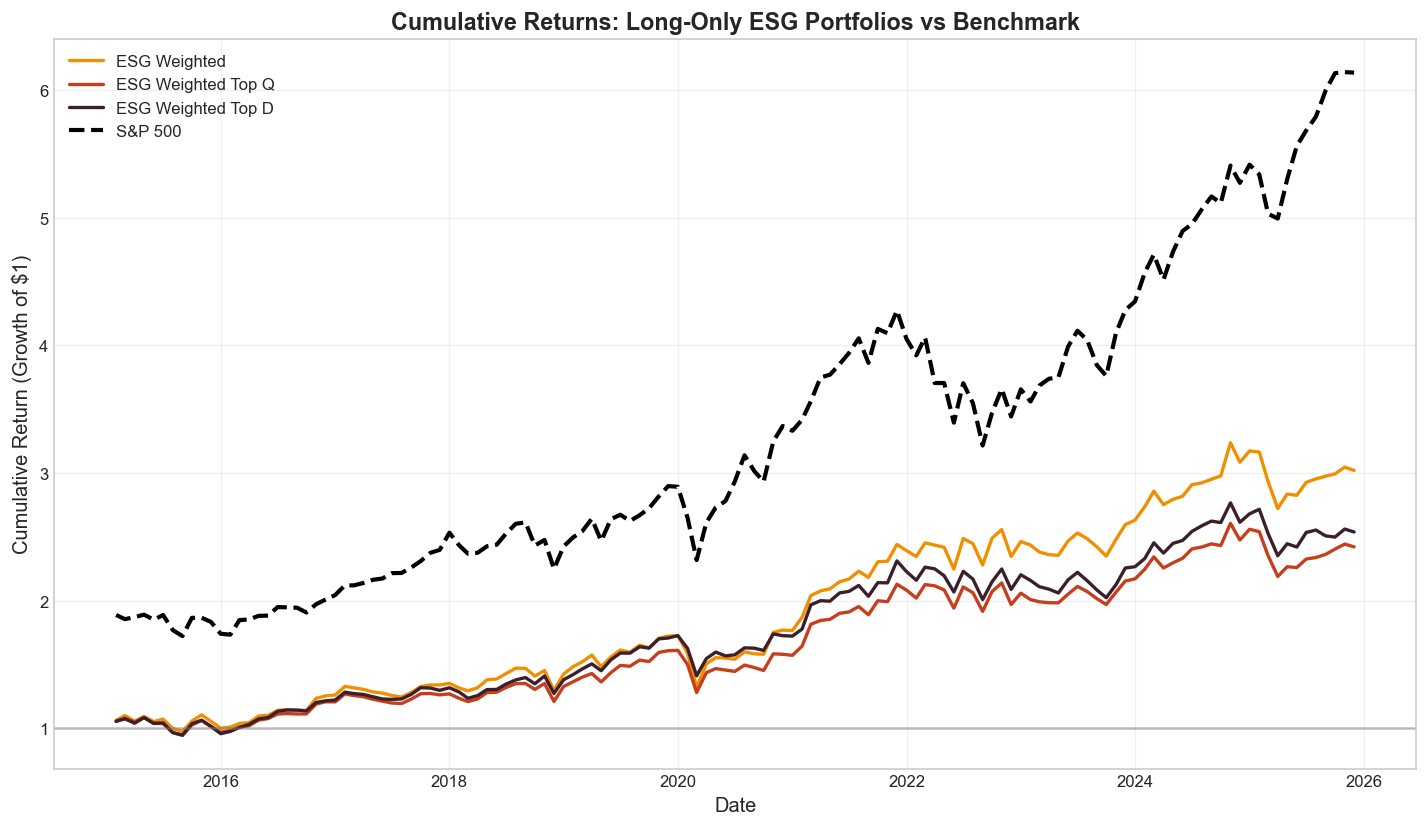

In [17]:
# PLOT 1: Cumulative Returns - Long-Only Portfolios vs Benchmark
fig, ax = plt.subplots(figsize=(12, 7))

long_only_ports = ['ESG Weighted', 'ESG Weighted Top Q', 'ESG Weighted Top D']

for name in long_only_ports:
    cum_ret = (1 + portfolios[name]).cumprod()
    ax.plot(cum_ret.index, cum_ret.values, 
            label=name, color=colors[name], linewidth=2)

# Benchmark
bench_cum = (1 + benchmark_series).cumprod()
bench_cum = bench_cum.reindex(portfolios['ESG Weighted'].index)
ax.plot(bench_cum.index, bench_cum.values, 
        label='S&P 500', color='black', linewidth=2.5, linestyle='--')

ax.set_title('Cumulative Returns: Long-Only ESG Portfolios vs Benchmark', 
              fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (Growth of $1)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=1, color='gray', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

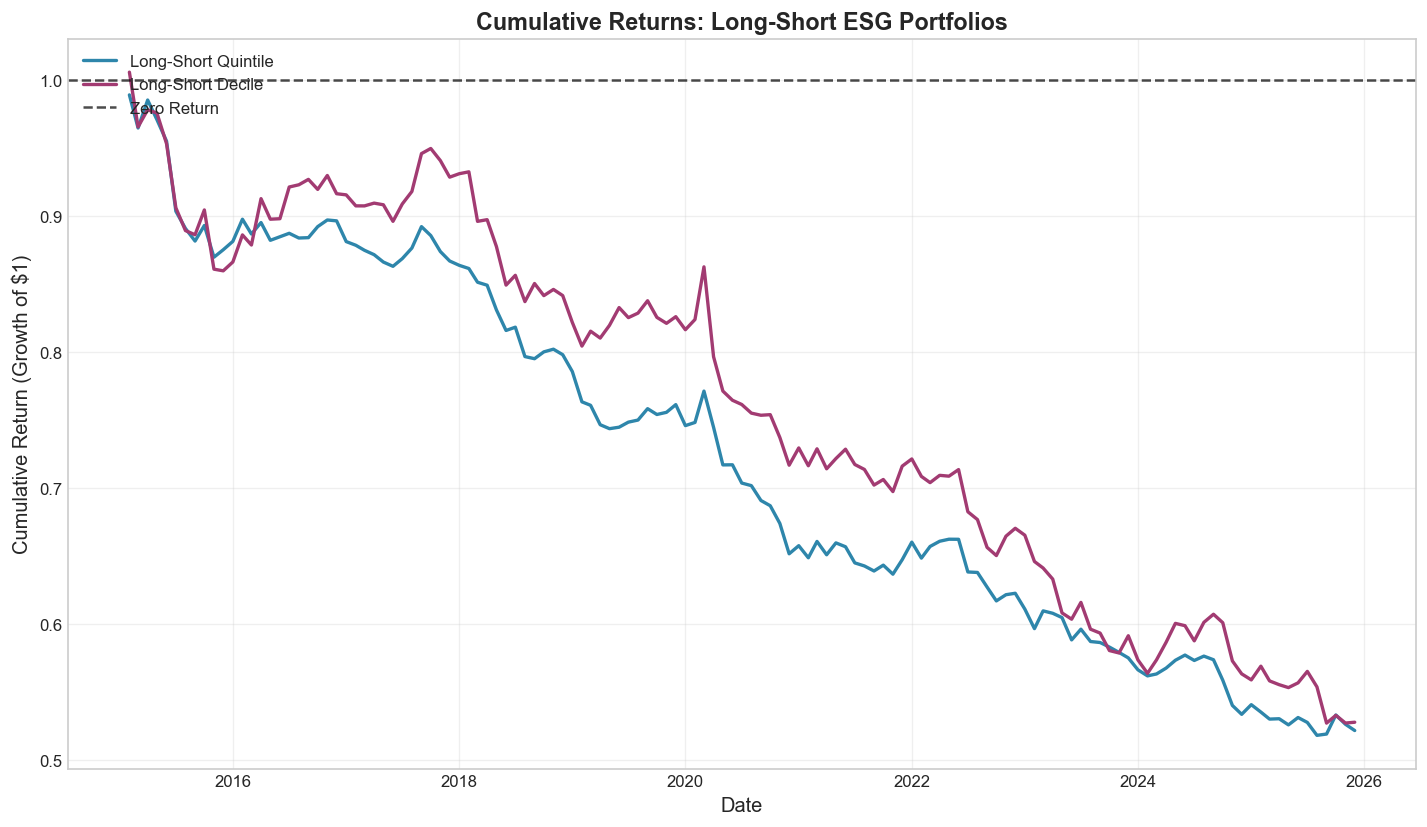

In [18]:
# PLOT 2: Long-Short Portfolio Performance
fig, ax = plt.subplots(figsize=(12, 7))

ls_ports = ['Long-Short Quintile', 'Long-Short Decile']

for name in ls_ports:
    cum_ret = (1 + portfolios[name]).cumprod()
    ax.plot(cum_ret.index, cum_ret.values, 
            label=name, color=colors[name], linewidth=2)

ax.axhline(y=1, color='black', linestyle='--', alpha=0.7, label='Zero Return')

ax.set_title('Cumulative Returns: Long-Short ESG Portfolios', 
              fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (Growth of $1)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

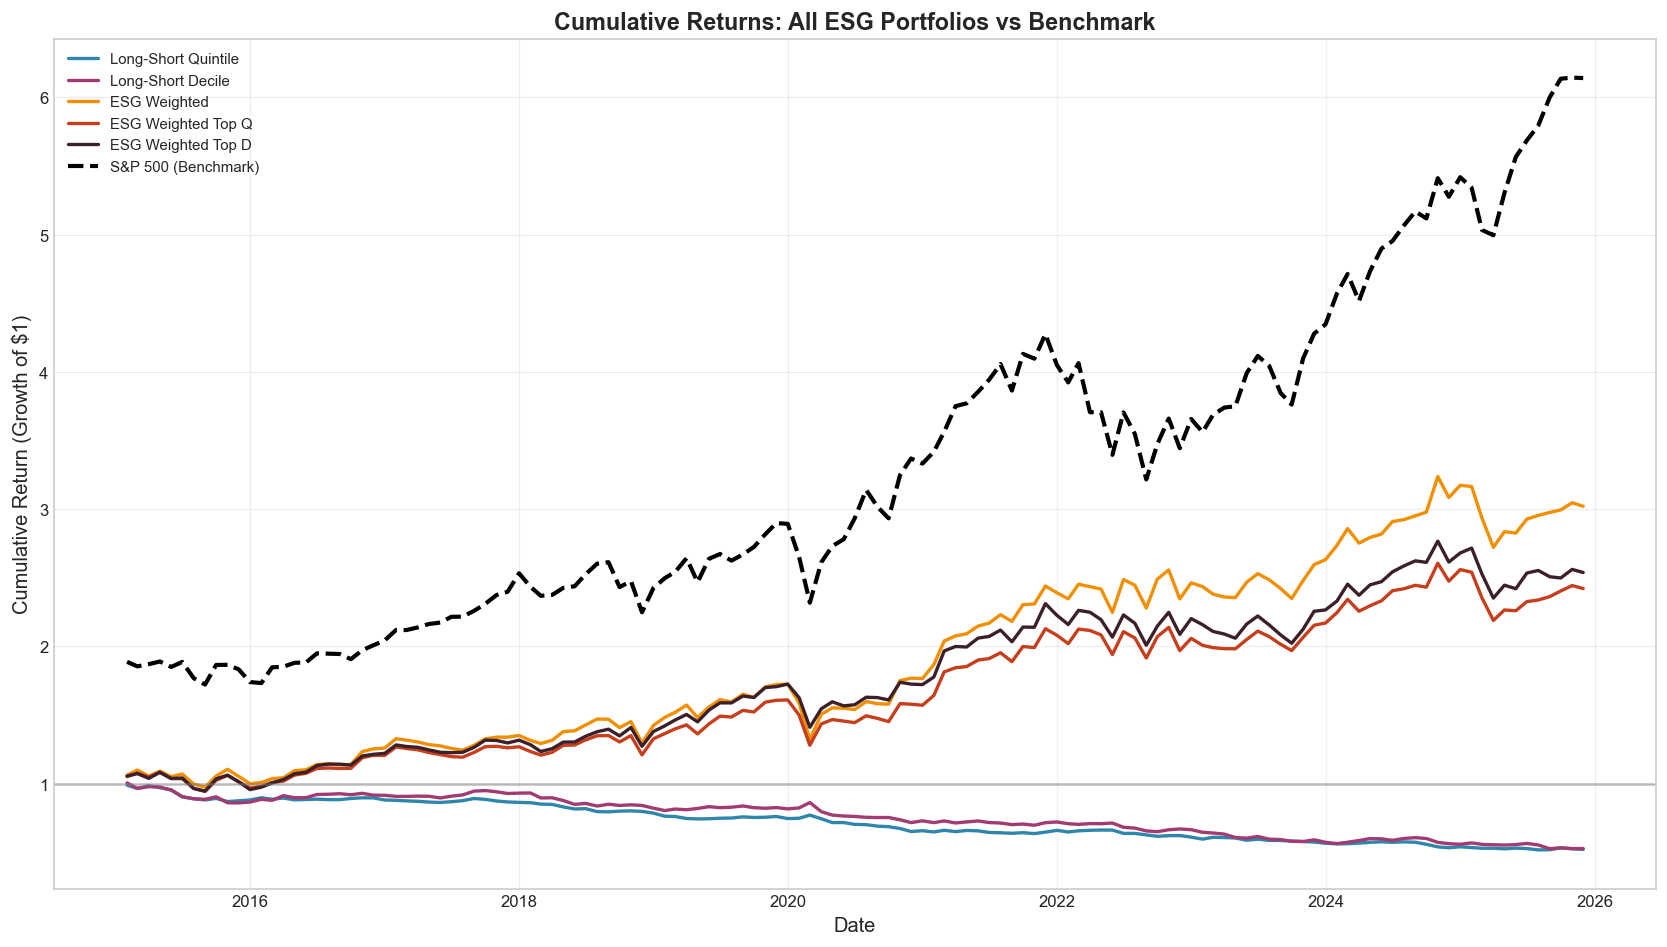

In [19]:
# PLOT 3: All Portfolios Comparison
fig, ax = plt.subplots(figsize=(14, 8))

for name, returns in portfolios.items():
    cum_ret = (1 + returns).cumprod()
    ax.plot(cum_ret.index, cum_ret.values, 
            label=name, color=colors[name], linewidth=2)

# Benchmark
bench_cum = (1 + benchmark_series).cumprod()
bench_cum = bench_cum.reindex(portfolios['ESG Weighted'].index)
ax.plot(bench_cum.index, bench_cum.values, 
        label='S&P 500 (Benchmark)', color='black', linewidth=2.5, linestyle='--')

ax.set_title('Cumulative Returns: All ESG Portfolios vs Benchmark', 
              fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (Growth of $1)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=1, color='gray', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

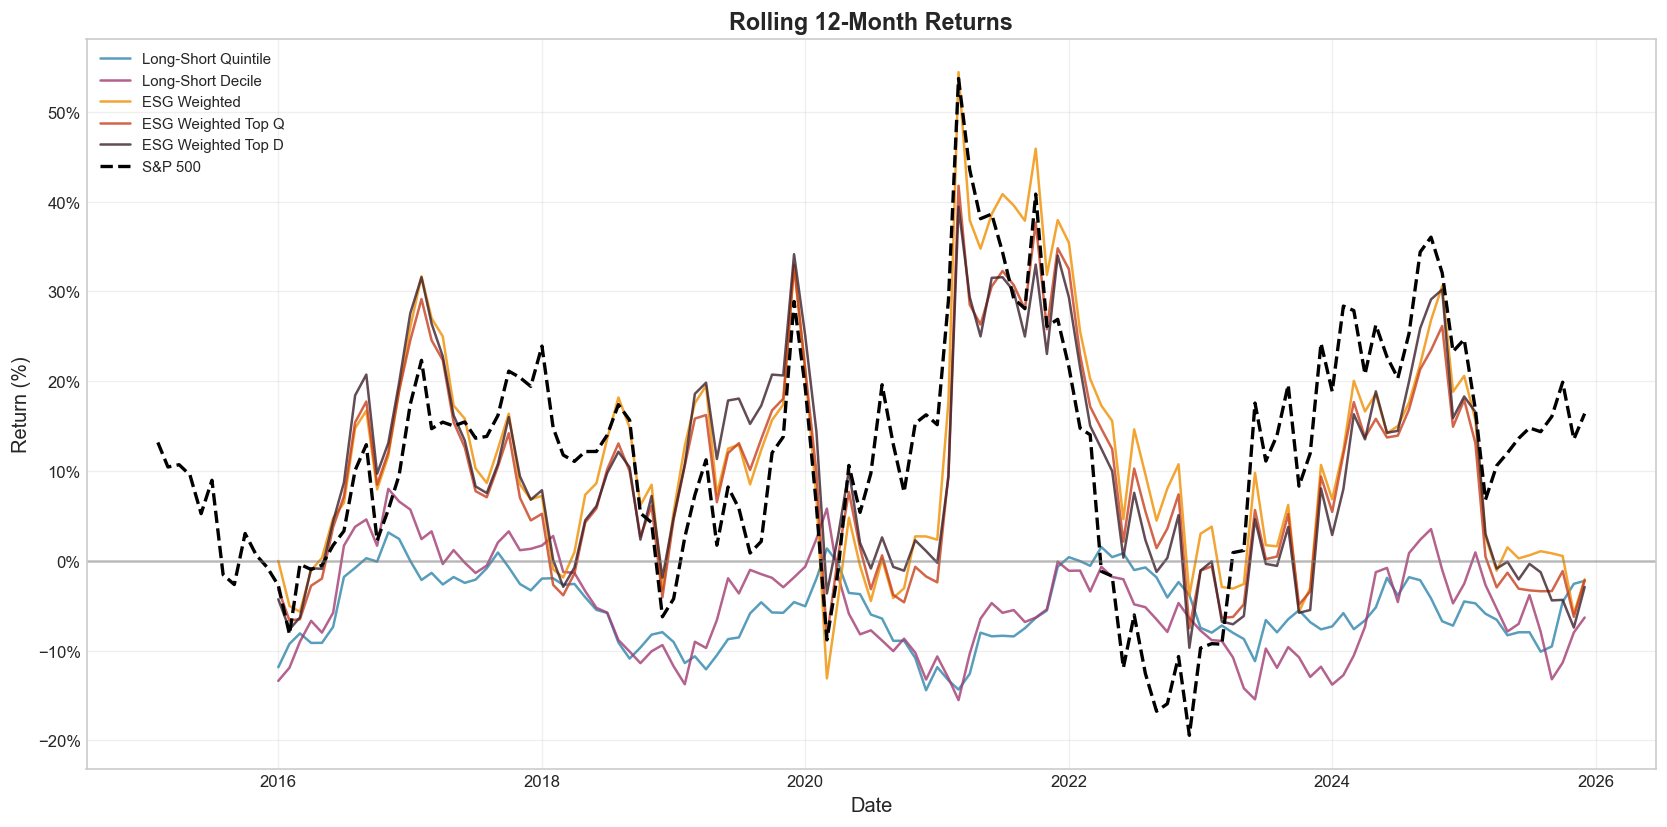

In [20]:
# PLOT 4: Rolling 12-Month Returns
fig, ax = plt.subplots(figsize=(14, 7))

for name, returns in portfolios.items():
    rolling_ret = returns.rolling(12).apply(lambda x: (1 + x).prod() - 1)
    ax.plot(rolling_ret.index, rolling_ret.values * 100, 
            label=name, color=colors[name], linewidth=1.5, alpha=0.8)

# Benchmark rolling
bench_rolling = benchmark_series.rolling(12).apply(lambda x: (1 + x).prod() - 1)
bench_rolling = bench_rolling.reindex(portfolios['ESG Weighted'].index)
ax.plot(bench_rolling.index, bench_rolling.values * 100, 
        label='S&P 500', color='black', linewidth=2, linestyle='--')

ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.set_title('Rolling 12-Month Returns', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Return (%)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

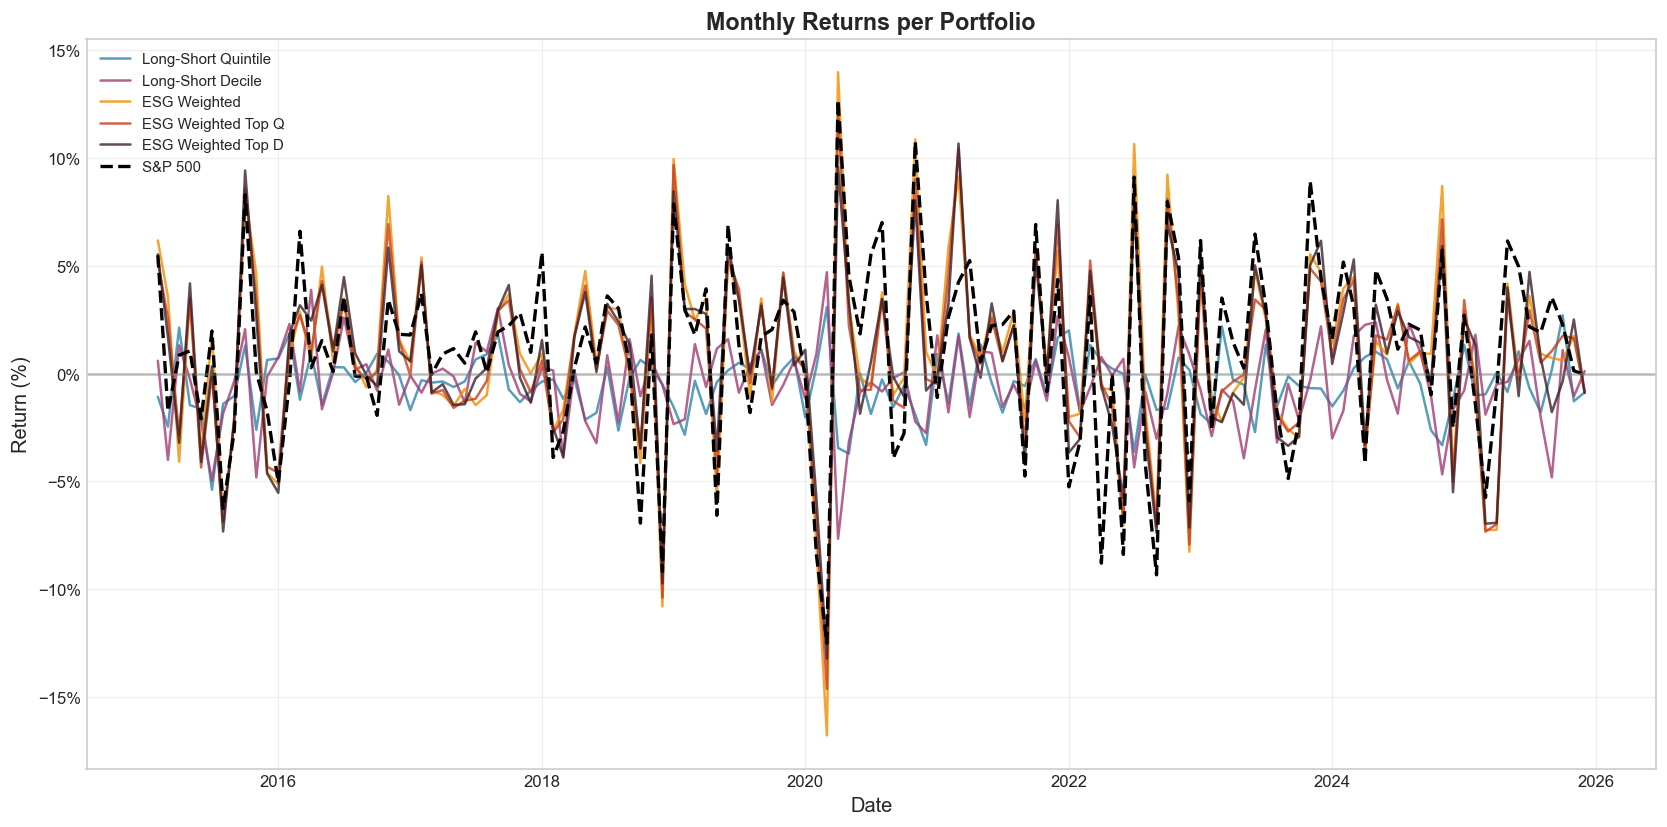

In [29]:
# Plot 4.2 - Monthly returns per portfolio
fig, ax = plt.subplots(figsize=(14, 7))
for name, returns in portfolios.items():
    ax.plot(returns.index, returns.values * 100, 
            label=name, color=colors[name], linewidth=1.5, alpha=0.8)
# Benchmark monthly returns
bench_monthly = benchmark_series.reindex(portfolios['ESG Weighted'].index)
ax.plot(bench_monthly.index, bench_monthly.values * 100,
        label='S&P 500', color='black', linewidth=2, linestyle='--')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.set_title('Monthly Returns per Portfolio', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Return (%)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()

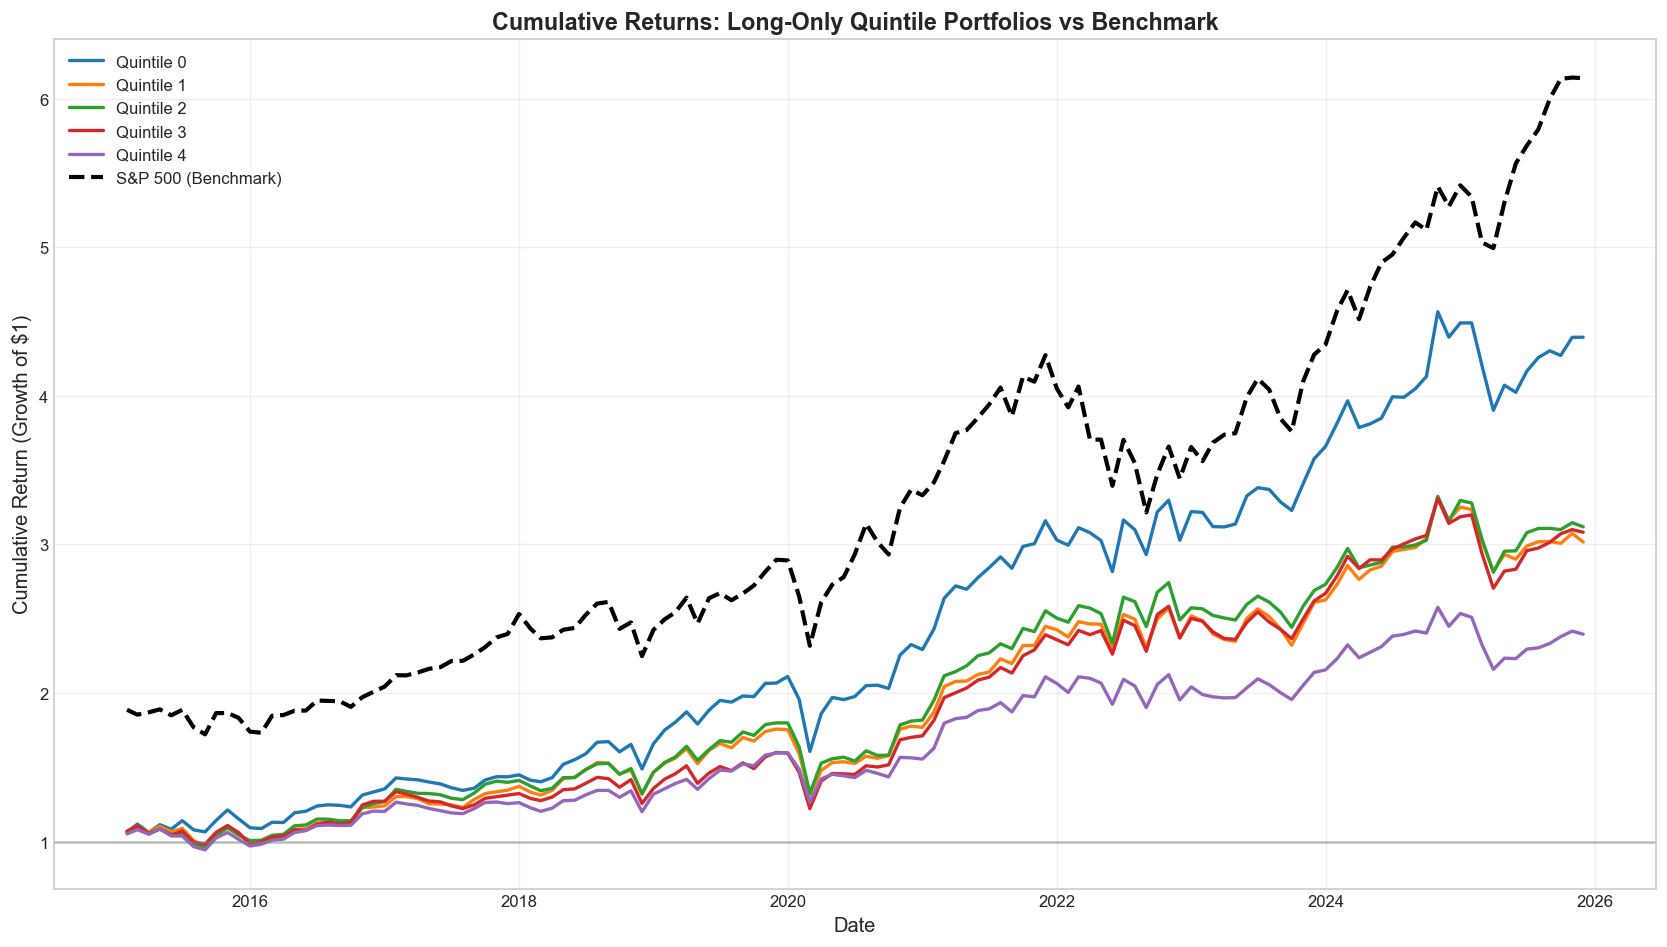

In [47]:
# See performance of all quintiles long only 
# Creates all the portfolios and then plots the cumulative returns of all quintiles (5 quintiles from best to worst)

def create_long_only_quintiles(data):
    """
    Create long-only portfolios for each ESG quintile
    """
    quintile_returns = data.groupby(['Date', 'ESG_quintile'])['Return'].mean().unstack()
    return quintile_returns

quintile_portfolios = create_long_only_quintiles(data)
fig, ax = plt.subplots(figsize=(14, 8))
for q in quintile_portfolios.columns:
    cum_ret = (1 + quintile_portfolios[q]).cumprod()
    ax.plot(cum_ret.index, cum_ret.values, 
            label=f'Quintile {q}', linewidth=2)
# Benchmark
bench_cum = (1 + benchmark_series).cumprod()
bench_cum = bench_cum.reindex(quintile_portfolios.index)
ax.plot(bench_cum.index, bench_cum.values, 
        label='S&P 500 (Benchmark)', color='black', linewidth=2.5, linestyle='--')
ax.set_title('Cumulative Returns: Long-Only Quintile Portfolios vs Benchmark', 
              fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (Growth of $1)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=1, color='gray', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()


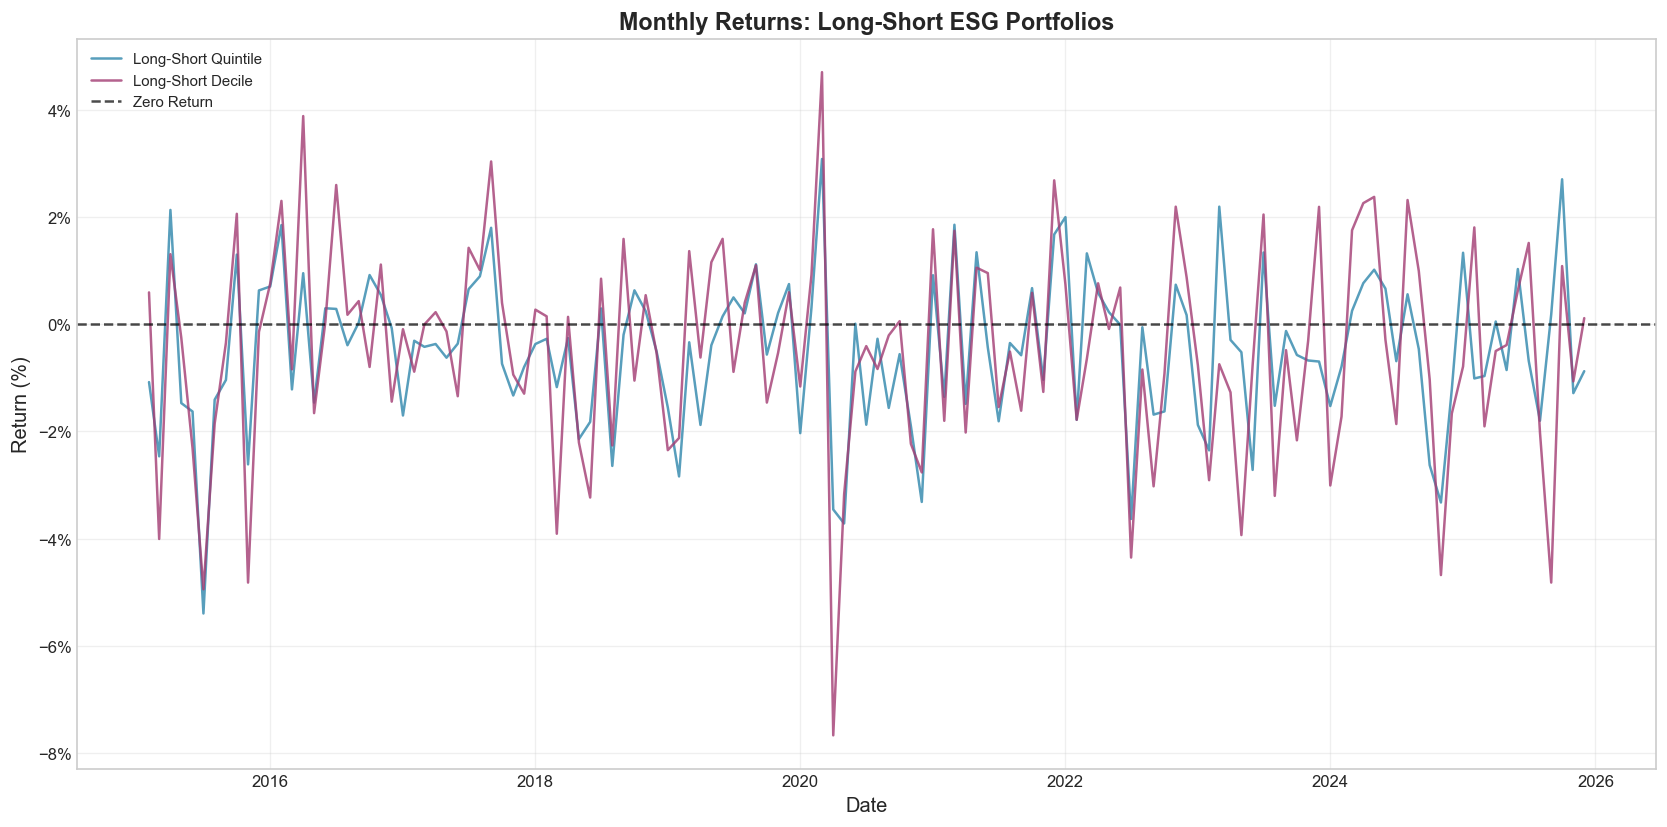

In [35]:
# Plot 4.3 - Monthly returns for Long-Short Portfolios
fig, ax = plt.subplots(figsize=(14, 7))
ls_ports = ['Long-Short Quintile', 'Long-Short Decile']
for name in ls_ports:
    returns = portfolios[name]
    ax.plot(returns.index, returns.values * 100, 
            label=name, color=colors[name], linewidth=1.5, alpha=0.8)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.7, label='Zero Return')
ax.set_title('Monthly Returns: Long-Short ESG Portfolios', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Return (%)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()

In [38]:
# Extract months where long/short = positive returns 
long_short_quintile_pos = portfolios['Long-Short Quintile'] > 0
long_short_decile_pos = portfolios['Long-Short Decile'] > 0
print("Months where Long-Short Quintile > 0:")
print(portfolios['Long-Short Quintile'][long_short_quintile_pos])
print("\nMonths where Long-Short Decile > 0:")
print(portfolios['Long-Short Decile'][long_short_decile_pos])

Months where Long-Short Quintile > 0:
Date
2015-04-01    0.021326
2015-10-01    0.012995
2015-12-01    0.006312
2016-01-01    0.007047
2016-02-01    0.018504
2016-04-01    0.009528
2016-06-01    0.002986
2016-07-01    0.002863
2016-09-01    0.000303
2016-10-01    0.009182
2016-11-01    0.005484
2017-07-01    0.006551
2017-08-01    0.008948
2017-09-01    0.017995
2018-07-01    0.002955
2018-10-01    0.006329
2018-11-01    0.002453
2019-06-01    0.001470
2019-07-01    0.005009
2019-08-01    0.002035
2019-09-01    0.011187
2019-11-01    0.002118
2019-12-01    0.007498
2020-02-01    0.003136
2020-03-01    0.030833
2020-06-01    0.000100
2021-01-01    0.009148
2021-03-01    0.018563
2021-05-01    0.013435
2021-10-01    0.006742
2021-12-01    0.016753
2022-01-01    0.019985
2022-03-01    0.013227
2022-04-01    0.005858
2022-05-01    0.002257
2022-11-01    0.007379
2022-12-01    0.001716
2023-03-01    0.021937
2023-07-01    0.013390
2024-03-01    0.002508
2024-04-01    0.007666
2024-05-01    

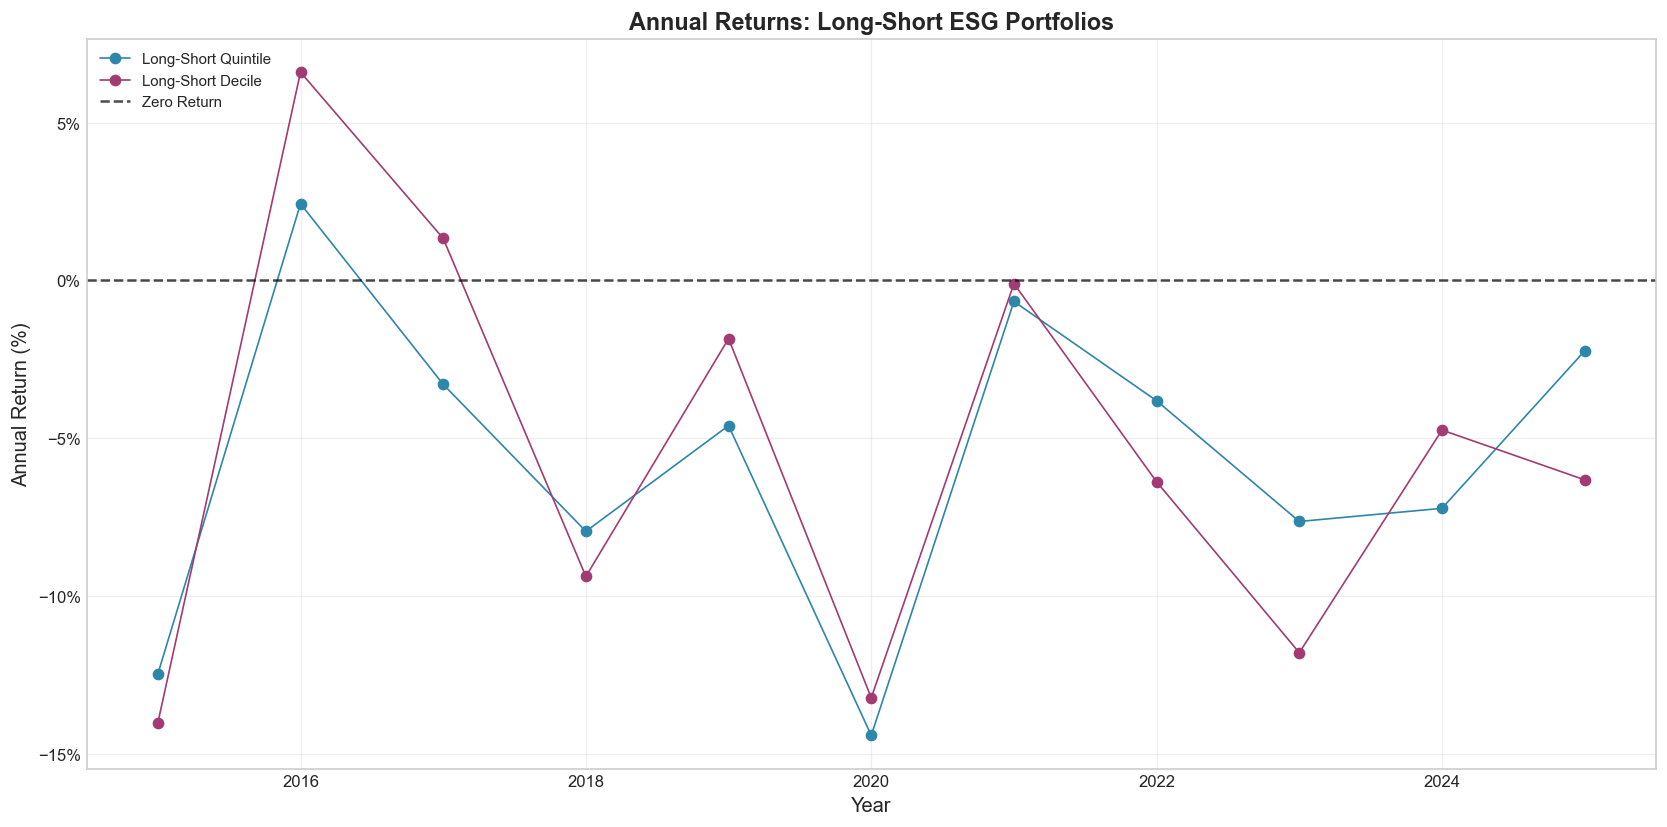

In [ ]:
# Plot 4.4 - Annual returns for Long/short portfolios
fig, ax = plt.subplots(figsize=(14, 7))
ls_ports = ['Long-Short Quintile', 'Long-Short Decile']
for name in ls_ports:
    returns = portfolios[name]
    annual_ret = returns.resample('Y').apply(lambda x: (1 + x).prod() - 1)
    ax.plot(annual_ret.index.year, annual_ret.values * 100, 
            label=name, color=colors[name], marker='o', linewidth=2)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.7, label='Zero Return')
ax.set_title('Annual Returns: Long-Short ESG Portfolios', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Annual Return (%)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()

In [ ]:
# Extract years where long/short = positive returns 
annual_ret = returns.resample('Y').apply(lambda x: (1 + x).prod() - 1)
long_short_quintile_pos = portfolios['Long-Short Quintile'] > 0
long_short_decile_pos = portfolios['Long-Short Decile'] > 0
print("Years where Long-Short Quintile > 0:")
print(portfolios['Long-Short Quintile'][long_short_quintile_pos])
print("\nYears where Long-Short Decile > 0:")
print(portfolios['Long-Short Decile'][long_short_decile_pos])

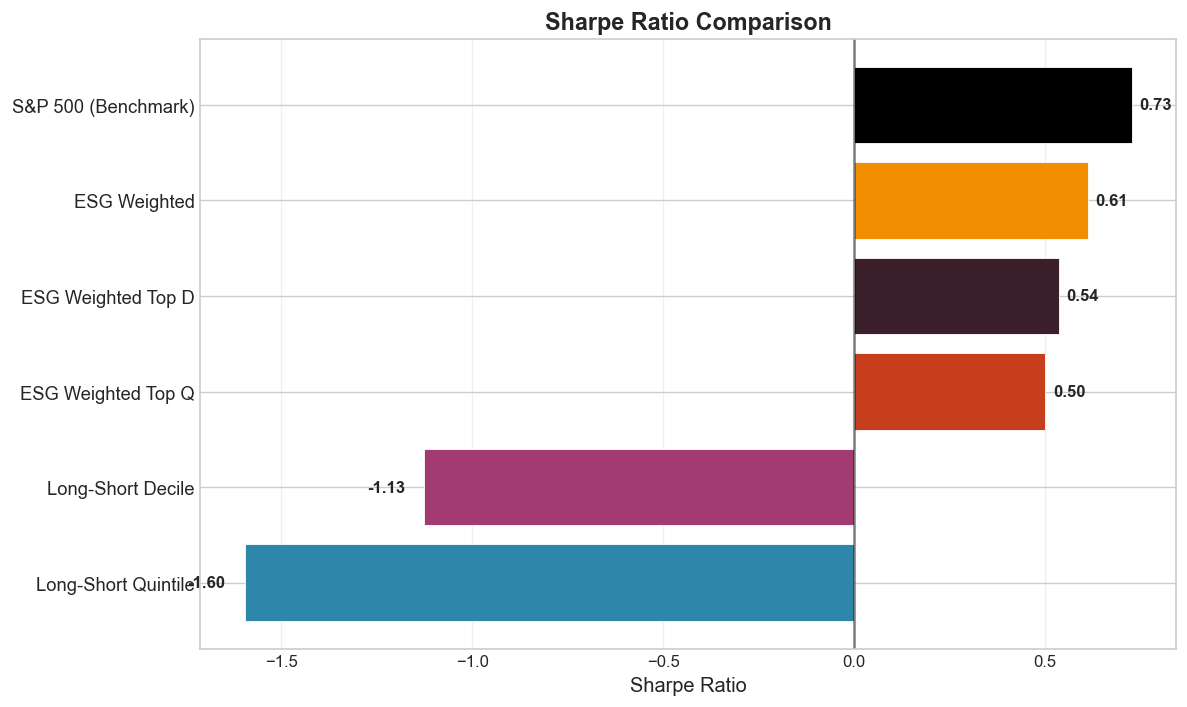

In [21]:
# PLOT 5: Sharpe Ratio Comparison
fig, ax = plt.subplots(figsize=(10, 6))

sharpe_data = metrics_df['Sharpe Ratio'].sort_values(ascending=True)
bar_colors = [colors.get(name, '#666666') for name in sharpe_data.index]

bars = ax.barh(range(len(sharpe_data)), sharpe_data.values, color=bar_colors, 
               edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(sharpe_data)))
ax.set_yticklabels(sharpe_data.index, fontsize=11)
ax.set_xlabel('Sharpe Ratio', fontsize=12)
ax.set_title('Sharpe Ratio Comparison', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', alpha=0.5)
ax.grid(True, alpha=0.3, axis='x')

# Add values on bars
for bar, val in zip(bars, sharpe_data.values):
    offset = 0.02 if val >= 0 else -0.15
    ax.text(val + offset, bar.get_y() + bar.get_height()/2, 
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

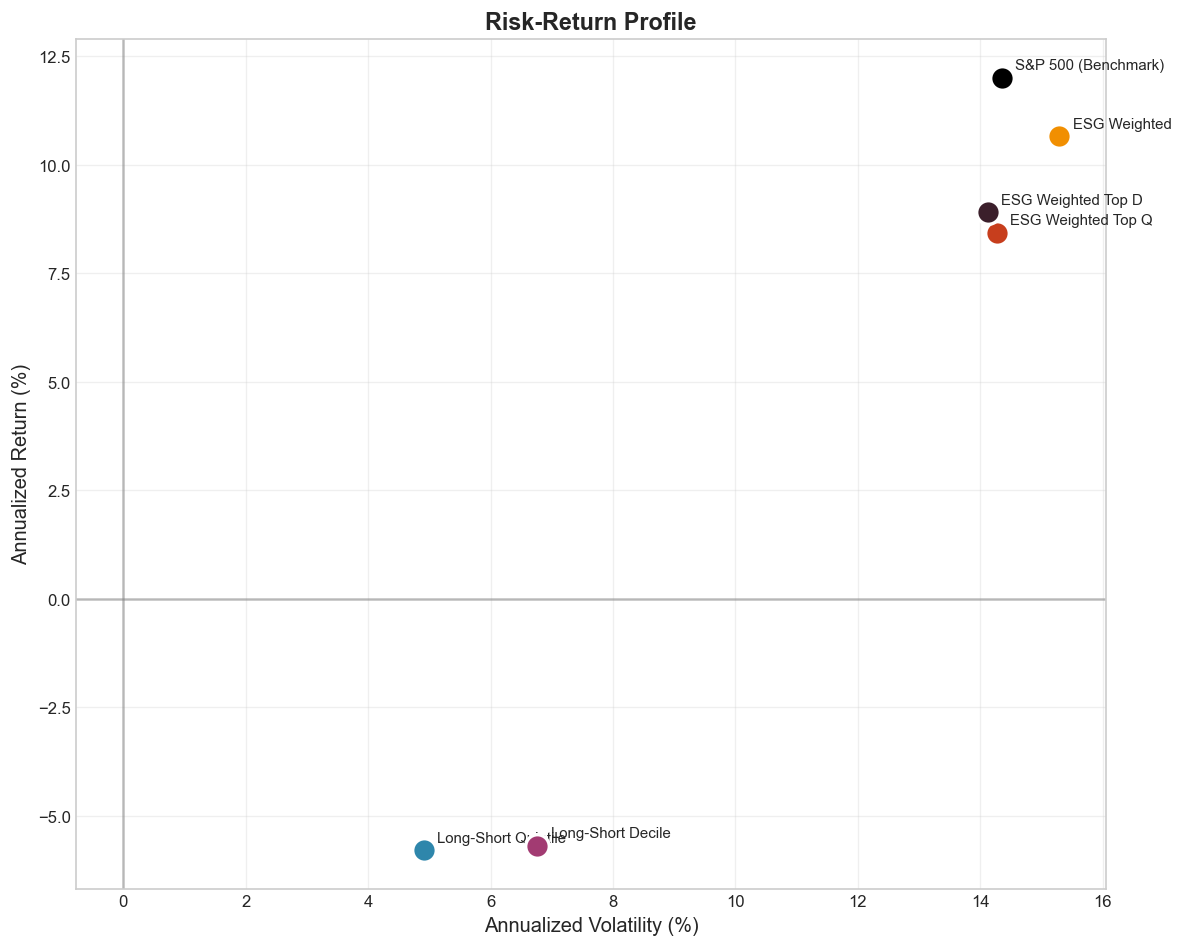

In [22]:
# PLOT 6: Risk-Return Scatter
fig, ax = plt.subplots(figsize=(10, 8))

all_names = list(portfolios.keys()) + ['S&P 500 (Benchmark)']

for name in all_names:
    ret = metrics_df.loc[name, 'Annualized Return'] * 100
    vol = metrics_df.loc[name, 'Annualized Volatility'] * 100
    
    ax.scatter(vol, ret, s=200, color=colors.get(name, '#000000'), 
               label=name, edgecolor='white', linewidth=2, zorder=5)
    ax.annotate(name, (vol, ret), textcoords="offset points", 
                xytext=(8, 5), fontsize=9)

ax.set_title('Risk-Return Profile', fontsize=14, fontweight='bold')
ax.set_xlabel('Annualized Volatility (%)', fontsize=12)
ax.set_ylabel('Annualized Return (%)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

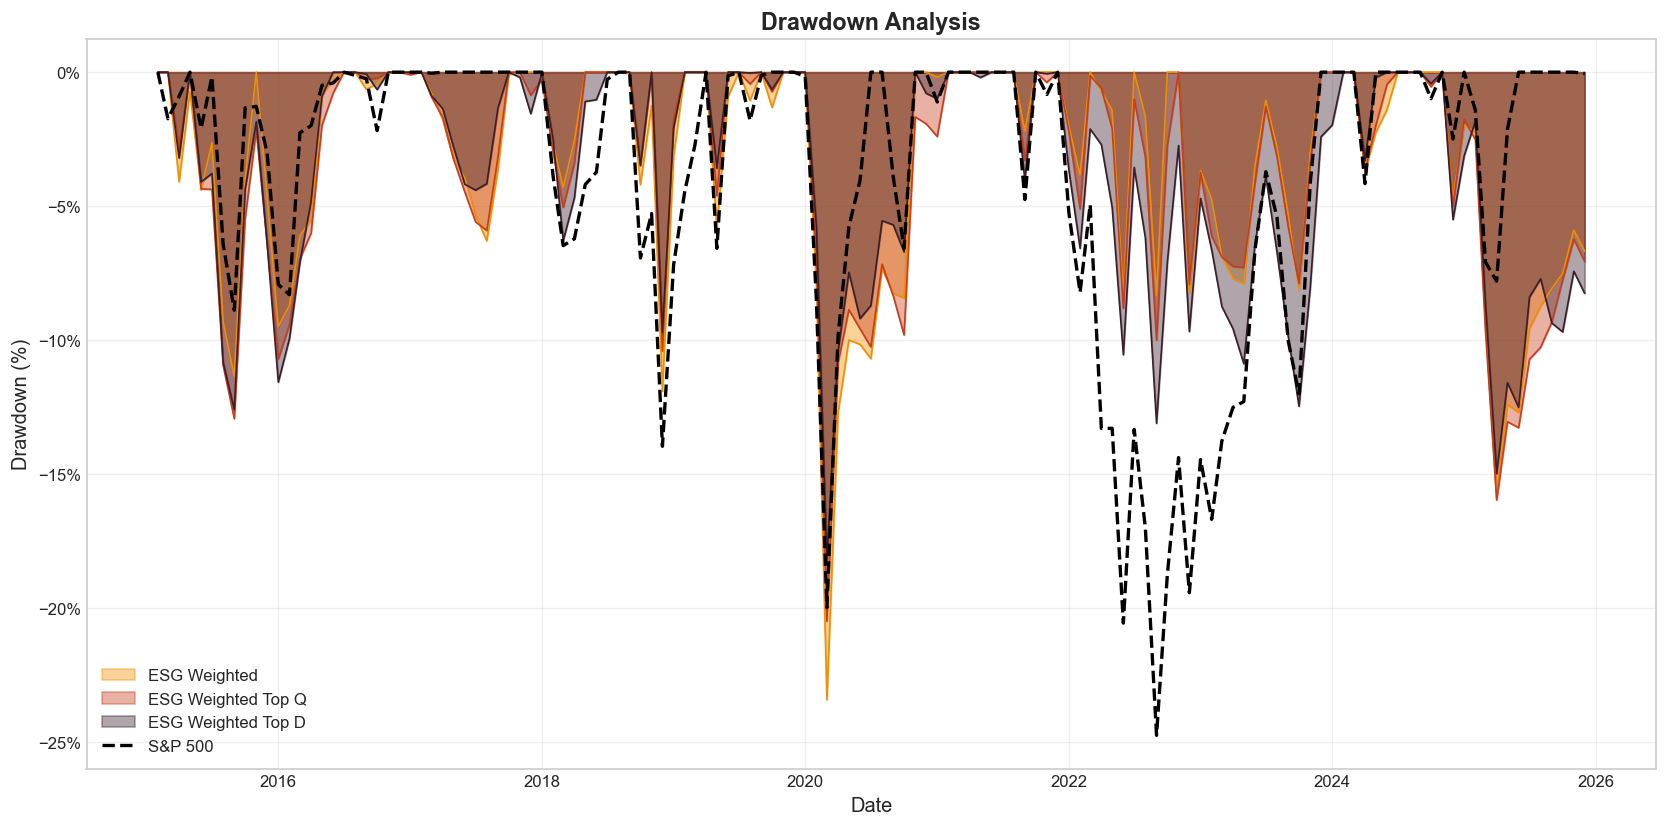

In [23]:
# PLOT 7: Drawdown Analysis
fig, ax = plt.subplots(figsize=(14, 7))

for name in ['ESG Weighted', 'ESG Weighted Top Q', 'ESG Weighted Top D']:
    cum_ret = (1 + portfolios[name]).cumprod()
    rolling_max = cum_ret.expanding().max()
    drawdown = (cum_ret / rolling_max - 1) * 100
    ax.fill_between(drawdown.index, drawdown.values, 0, 
                    label=name, alpha=0.4, color=colors[name])
    ax.plot(drawdown.index, drawdown.values, color=colors[name], linewidth=1)

# Benchmark drawdown
bench_cum = (1 + benchmark_series).cumprod()
bench_cum = bench_cum.reindex(portfolios['ESG Weighted'].index)
bench_rolling_max = bench_cum.expanding().max()
bench_dd = (bench_cum / bench_rolling_max - 1) * 100
ax.plot(bench_dd.index, bench_dd.values, 
        label='S&P 500', color='black', linewidth=2, linestyle='--')

ax.set_title('Drawdown Analysis', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown (%)', fontsize=12)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

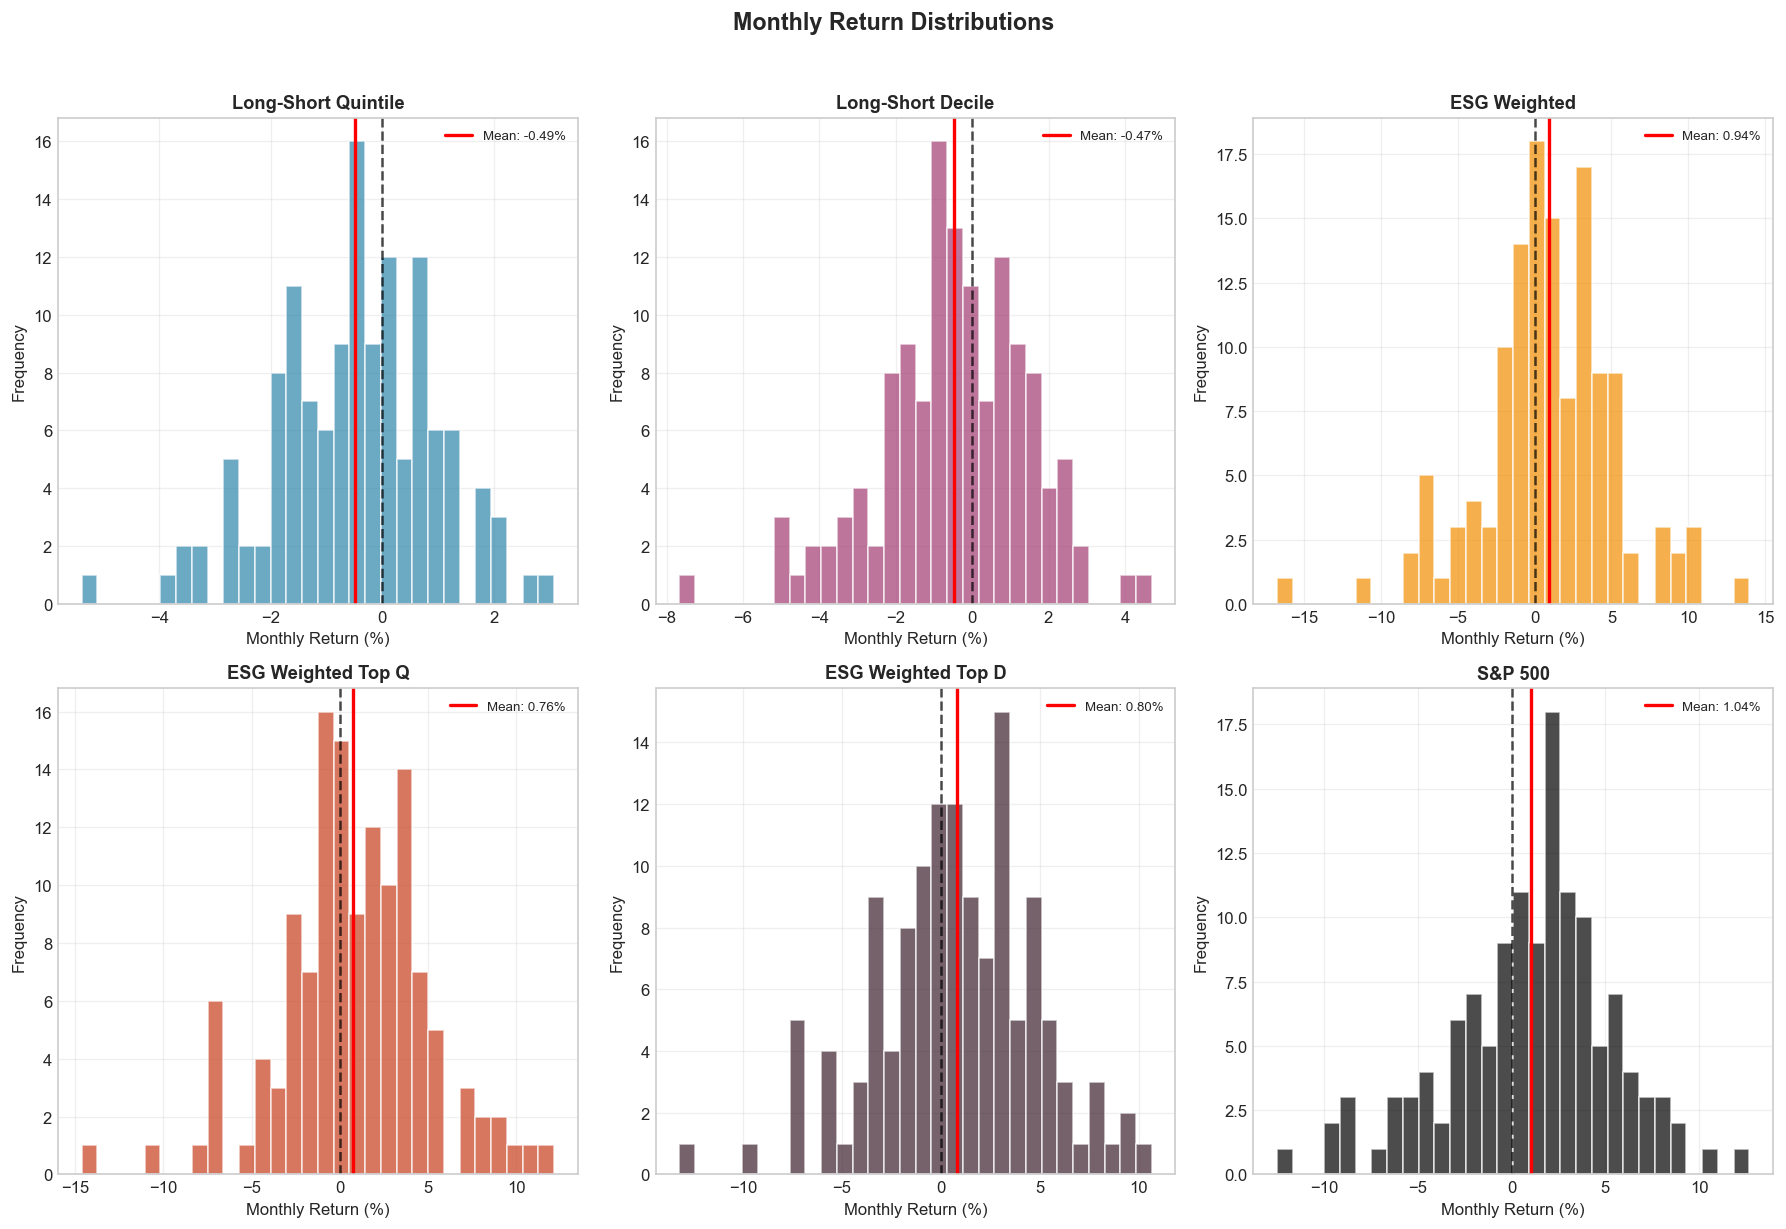

In [24]:
# PLOT 8: Monthly Return Distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

all_returns = {**portfolios}
all_returns['S&P 500'] = benchmark_series.reindex(portfolios['ESG Weighted'].index)

for idx, (name, returns) in enumerate(all_returns.items()):
    ax = axes[idx]
    color = colors.get(name, colors.get('S&P 500 (Benchmark)', '#666666'))
    
    ax.hist(returns.dropna().values * 100, bins=30, alpha=0.7, 
            color=color, edgecolor='white')
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.7)
    ax.axvline(x=returns.mean()*100, color='red', linestyle='-', 
               linewidth=2, label=f'Mean: {returns.mean()*100:.2f}%')
    
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Monthly Return (%)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Monthly Return Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Export Results

In [25]:
# Export metrics to CSV
metrics_df.to_csv('esg_portfolio_metrics.csv')

# Export portfolio returns
portfolio_df.to_csv('esg_portfolio_returns.csv')

print("Results exported:")
print("  - esg_portfolio_metrics.csv")
print("  - esg_portfolio_returns.csv")

Results exported:
  - esg_portfolio_metrics.csv
  - esg_portfolio_returns.csv


## 7. Summary Statistics

In [26]:
# Final Summary
print("="*80)
print("ESG PORTFOLIO ANALYSIS - KEY FINDINGS")
print("="*80)

# Best performer by Sharpe
best_sharpe = metrics_df['Sharpe Ratio'].idxmax()
print(f"\n🏆 Best Sharpe Ratio: {best_sharpe} ({metrics_df.loc[best_sharpe, 'Sharpe Ratio']:.3f})")

# Best performer by Return
best_return = metrics_df['Annualized Return'].idxmax()
print(f"📈 Highest Return: {best_return} ({metrics_df.loc[best_return, 'Annualized Return']*100:.2f}%)")

# Lowest volatility
lowest_vol = metrics_df['Annualized Volatility'].idxmin()
print(f"📉 Lowest Volatility: {lowest_vol} ({metrics_df.loc[lowest_vol, 'Annualized Volatility']*100:.2f}%)")

# Best Alpha
best_alpha = metrics_df['Alpha (ann.)'].idxmax()
print(f"🎯 Highest Alpha: {best_alpha} ({metrics_df.loc[best_alpha, 'Alpha (ann.)']*100:.2f}%)")

# Smallest Drawdown
best_dd = metrics_df['Max Drawdown'].idxmax()  # Closest to 0 (least negative)
print(f"🛡️ Smallest Drawdown: {best_dd} ({metrics_df.loc[best_dd, 'Max Drawdown']*100:.2f}%)")

print("\n" + "="*80)

ESG PORTFOLIO ANALYSIS - KEY FINDINGS

🏆 Best Sharpe Ratio: S&P 500 (Benchmark) (0.726)
📈 Highest Return: S&P 500 (Benchmark) (12.01%)
📉 Lowest Volatility: Long-Short Quintile (4.91%)
🎯 Highest Alpha: ESG Weighted (0.23%)
🛡️ Smallest Drawdown: ESG Weighted Top D (-18.25%)



## 8. Alpha analysis

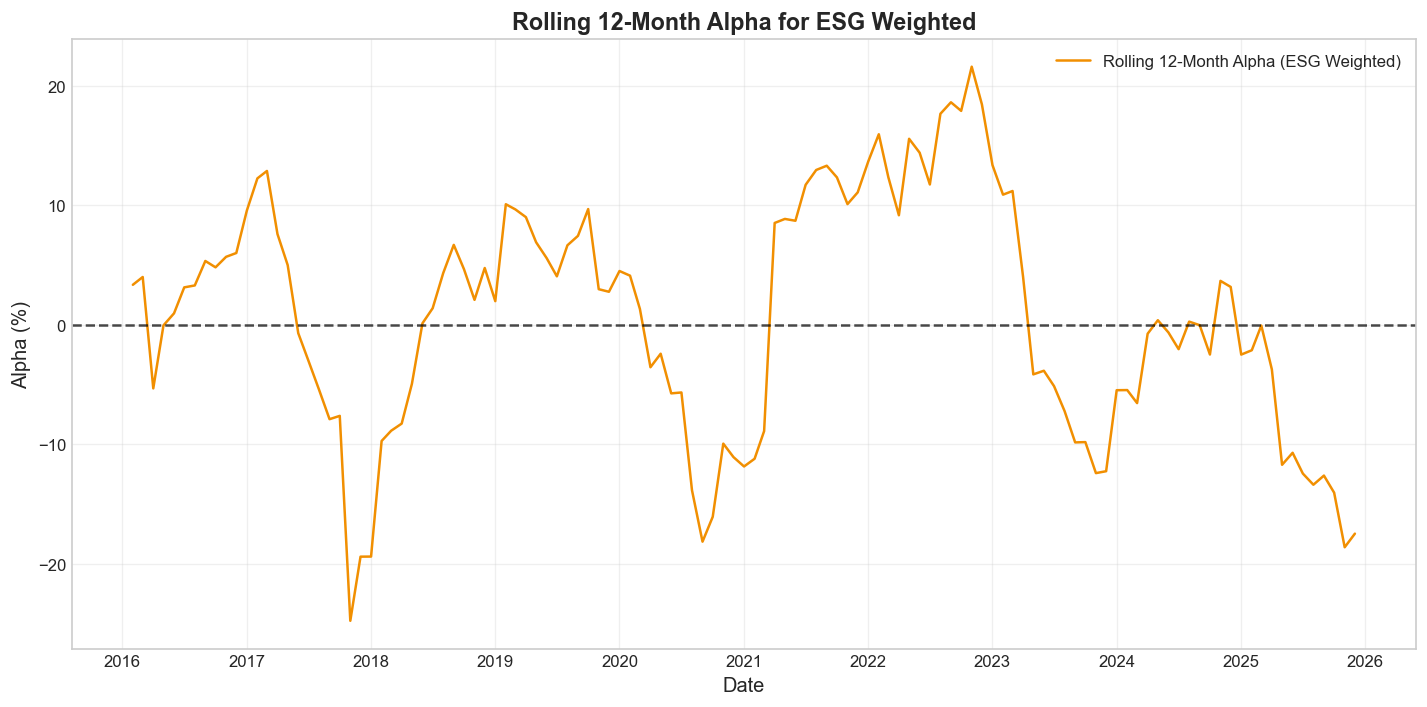

In [28]:
# Plot alpha over time for the best long-only portfolio 
plt.figure(figsize=(12,6))
best_long_only = "ESG Weighted"
best_portfolio_rets = portfolios[best_long_only]
# Calculate rolling alpha
rolling_alpha = []
for i in range(12, len(best_portfolio_rets)):
    port_slice = best_portfolio_rets.iloc[i-12:i]
    bench_slice = benchmark_series.reindex(port_slice.index)
    alpha = calculate_performance_metrics(port_slice, bench_slice, rf_rate_monthly)['Alpha (ann.)']
    rolling_alpha.append(alpha * 100)
alpha_dates = best_portfolio_rets.index[12:]
plt.plot(alpha_dates, rolling_alpha, label=f'Rolling 12-Month Alpha ({best_long_only})', color=colors[best_long_only])
plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
plt.title(f'Rolling 12-Month Alpha for {best_long_only}', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Alpha (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
